# Mutation Decay Experiment

This notebook evaluates the impact of dynamic mutation decay in a Genetic Algorithm designed to recreate *Girl with a Pearl Earring* using semi-transparent triangles.

Unlike fixed mutation strategies, mutation decay gradually reduces the mutation intensity throughout evolution. This allows the algorithm to explore more aggressively during the early generations while performing finer refinements during later stages.

The objective of this experiment is to compare different initial mutation rates and analyze their influence on:
- convergence speed;
- final RMSE;
- image quality;
- evolutionary stability.

In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ga_core import *

## Reproducibility

To ensure consistent and reproducible experiments, a fixed random seed is used for both Python's random module and NumPy.

In [12]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

## Experimental Configuration

The following parameters define the evolutionary setup used in the mutation decay experiments.

A relatively small population size and 1000 generations were selected to balance execution time and convergence quality while still allowing meaningful comparisons between mutation strategies.

In [13]:
POP_SIZE = 30
GENERATIONS = 1000

ELITE_SIZE = 3
TOURNAMENT_SIZE = 5

INITIAL_MUTATION_RATES = [0.03, 0.05, 0.08, 0.12]

## Target Image

The target image used throughout the experiments is *Girl with a Pearl Earring*.  
The image is resized and converted to RGB format before being processed by the Genetic Algorithm.

In [ ]:
target = load_target_image("girl_pearl_earing.png")

The following image represents the optimization target used during the evolutionary process.

In [ ]:
plt.figure(figsize=(4, 5))

plt.imshow(target)
plt.title("Target Image")
plt.axis("off")

plt.show()

## Mutation Decay Experiment Function

The following function runs the Genetic Algorithm several times, each time using a different initial mutation rate.

In all experiments, the mutation rate is not kept constant. Instead, it follows a decay schedule, starting from the selected initial value and gradually decreasing until reaching a minimum value of `0.01`.

This setup allows the algorithm to begin with stronger exploration and progressively shift toward more stable refinement.

In [ ]:
def run_mutation_decay_experiment(
    target_img,
    initial_mutation_rates,
    pop_size=POP_SIZE,
    generations=GENERATIONS,
    elite_size=ELITE_SIZE,
    tournament_size=TOURNAMENT_SIZE
):
    """
    Runs the GA with different initial mutation rates using mutation decay.
    Each mutation rate decreases progressively until reaching 0.01.
    """
    results = {}

    for rate in initial_mutation_rates:
        print("=" * 60)
        print(f"Testing initial mutation rate with decay: {rate}")

        result = evolve_configurable(
            target_img=target_img,
            pop_size=pop_size,
            generations=generations,
            mutation_rate=rate,
            elite_size=elite_size,
            selection_type="tournament",
            tournament_size=tournament_size,
            crossover_type="one_point",
            crossover_rate=1.0,
            use_mutation_decay=True,
            min_mutation_rate=0.01,
            snapshot_generations=[0, generations - 1],
            print_every=100
        )

        best_rend = render_individual(
            result["best_individual"],
            result["background_color"]
        )

        final_rmse = calculate_fitness(best_rend, target_img)

        results[rate] = {
            "best_individual": result["best_individual"],
            "history": result["history"],
            "background_color": result["background_color"],
            "snapshots": result["snapshots"],
            "mutation_rate_history": result["mutation_rate_history"],
            "final_image": best_rend,
            "final_rmse": final_rmse
        }

        print(f"Final RMSE for initial mutation rate {rate}: {final_rmse:.4f}")

    return results

## Running the Experiments

The experiments are executed using different initial mutation rates in order to analyze their effect on convergence and final image quality.

In [16]:
mutation_decay_results = run_mutation_decay_experiment(
    target_img=target,
    initial_mutation_rates=INITIAL_MUTATION_RATES,
    pop_size=POP_SIZE,
    generations=GENERATIONS,
    elite_size=ELITE_SIZE,
    tournament_size=TOURNAMENT_SIZE
)

Testing initial mutation rate with decay: 0.03
Generation 00000 | Best RMSE: 56.4600 | Mutation: 0.0300
Generation 00100 | Best RMSE: 41.4163 | Mutation: 0.0270
Generation 00200 | Best RMSE: 35.3061 | Mutation: 0.0240
Generation 00300 | Best RMSE: 32.5546 | Mutation: 0.0210
Generation 00400 | Best RMSE: 30.6233 | Mutation: 0.0180
Generation 00500 | Best RMSE: 29.0529 | Mutation: 0.0150
Generation 00600 | Best RMSE: 28.0194 | Mutation: 0.0120
Generation 00700 | Best RMSE: 27.1634 | Mutation: 0.0100
Generation 00800 | Best RMSE: 26.5556 | Mutation: 0.0100
Generation 00900 | Best RMSE: 26.0914 | Mutation: 0.0100
Generation 00999 | Best RMSE: 25.6982 | Mutation: 0.0100
Final RMSE for initial mutation rate 0.03: 25.6982
Testing initial mutation rate with decay: 0.05
Generation 00000 | Best RMSE: 54.9096 | Mutation: 0.0500
Generation 00100 | Best RMSE: 40.3157 | Mutation: 0.0450
Generation 00200 | Best RMSE: 35.2918 | Mutation: 0.0400
Generation 00300 | Best RMSE: 33.1573 | Mutation: 0.0350


## Convergence Analysis

The following plot compares the evolution of the best RMSE across generations for each initial mutation rate.

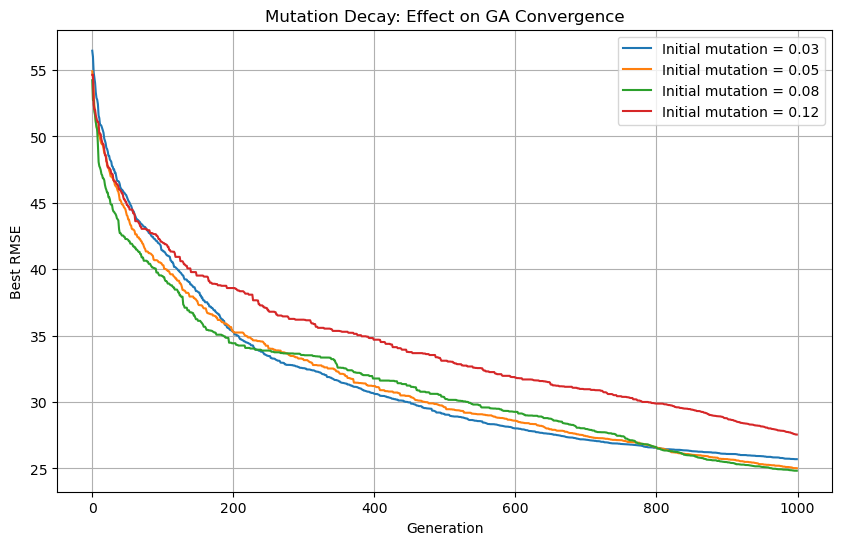

In [17]:
plt.figure(figsize=(10, 6))

for rate, result in mutation_decay_results.items():
    plt.plot(
        result["history"],
        label=f"Initial mutation = {rate}"
    )

plt.title("Mutation Decay: Effect on GA Convergence")
plt.xlabel("Generation")
plt.ylabel("Best RMSE")
plt.legend()
plt.grid(True)
plt.show()

## Mutation Decay Schedule

The following plot illustrates how the mutation rate changes throughout the evolutionary process.

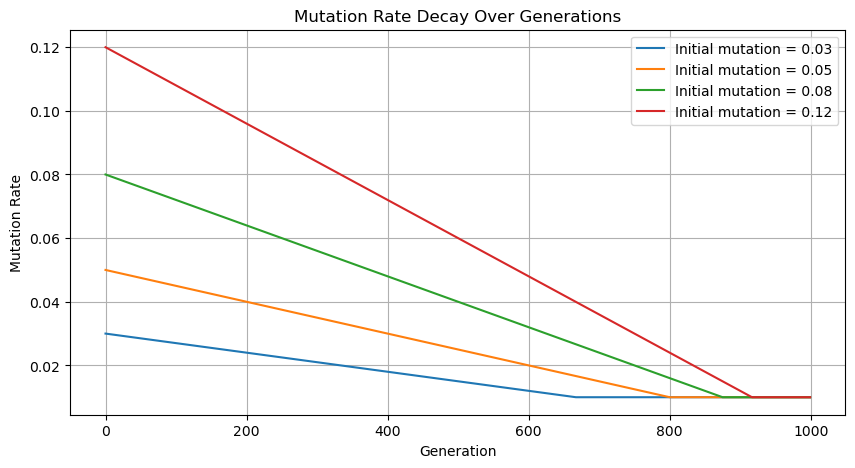

In [18]:
plt.figure(figsize=(10, 5))

for rate, result in mutation_decay_results.items():
    plt.plot(
        result["mutation_rate_history"],
        label=f"Initial mutation = {rate}"
    )

plt.title("Mutation Rate Decay Over Generations")
plt.xlabel("Generation")
plt.ylabel("Mutation Rate")
plt.legend()
plt.grid(True)
plt.show()

## Summary of Results

The table below summarizes the final RMSE and improvement obtained by each mutation decay configuration.

In [19]:
summary = []

for rate, result in mutation_decay_results.items():
    summary.append({
        "Initial Mutation Rate": rate,
        "Final RMSE": result["final_rmse"],
        "Initial RMSE": result["history"][0],
        "Improvement": result["history"][0] - result["final_rmse"]
    })

summary_df = pd.DataFrame(summary)
summary_df = summary_df.sort_values(by="Final RMSE")

summary_df

,Initial Mutation Rate,Final RMSE,Initial RMSE,Improvement
2,0.08,24.828392,54.239784,29.411392
1,0.05,25.017197,54.909611,29.892414
0,0.03,25.698181,56.460011,30.761829
3,0.12,27.552082,54.650600,27.098518


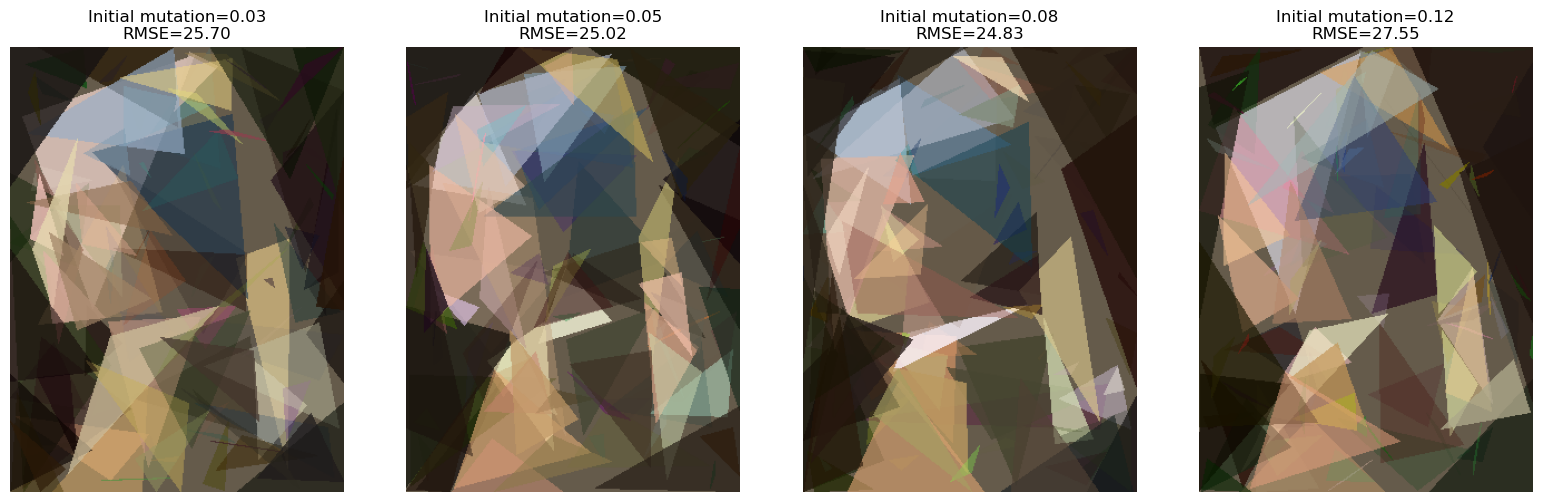

In [20]:
num_results = len(mutation_decay_results)

fig, axes = plt.subplots(
    1,
    num_results,
    figsize=(4 * num_results, 5)
)

if num_results == 1:
    axes = [axes]

for ax, (rate, result) in zip(axes, mutation_decay_results.items()):
    ax.imshow(result["final_image"])
    ax.set_title(
        f"Initial mutation={rate}\nRMSE={result['final_rmse']:.2f}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

## Best Configuration

Among all tested configurations, the best result was obtained using an initial mutation rate of `0.08`.

In [21]:
best_rate = min(
    mutation_decay_results,
    key=lambda rate: mutation_decay_results[rate]["final_rmse"]
)

best_result = mutation_decay_results[best_rate]

print(f"Best initial mutation rate: {best_rate}")
print(f"Best final RMSE: {best_result['final_rmse']:.4f}")

Best initial mutation rate: 0.08
Best final RMSE: 24.8284


# Conclusion

This experiment demonstrates that mutation decay can improve the behavior of the Genetic Algorithm by dynamically adapting the intensity of mutation during the evolutionary process.

The results show that using a fixed low mutation rate may lead to stable but less exploratory search, while an excessively high mutation rate may introduce too much disruption and slow down convergence. A dynamic mutation schedule provides a compromise between these two behaviors.

Among the tested configurations, an initial mutation rate of `0.08` achieved the best final RMSE. This indicates that stronger early exploration followed by gradual refinement is beneficial for this image approximation problem.

Overall, the mutation decay strategy provides a more flexible and adaptive mutation mechanism than using a constant mutation rate throughout the entire run.